# Thompson Sampling — Replay Scheme Comparison

Five conditions on the noisy bandit:
no replay · uniform replay · TD-error replay · uncertainty replay · EVB replay.

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt

from environments import NoisyBandit
from bayesian_qlearning import NormalGamma
from replay_buffer import PrioritizedReplayBuffer, Experience

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Environment

In [2]:
# Set BANDIT = "easy"  →  5-arm  (σ≈0.6, gap=0.7, SNR≈1.0, 1 000 steps)
    # BANDIT = "medium"  →  8-arm (σ=1.0,  gap=0.5, SNR≈0.6, 1 500 steps)
#     BANDIT = "hard"  →  10-arm (σ=1.5,  gap=0.3, SNR≈0.2, 2 000 steps)
BANDIT = "easy"

CONFIGS = {
    "easy": dict(
        means       = np.array([0.2, 0.8, 1.5, 0.5, 1.0]),
        stds        = np.array([0.5, 0.8, 0.6, 1.0, 0.7]),
        n_steps     = 2_000,
        window      = 50,
        description = "5-arm, σ≈0.6, gap=0.7, SNR≈1.0",
    ),
    # "medium": dict(
    #     means       = np.array([0.2, 0.8, 1.5, 0.5, 1.0]),
    #     stds        = np.array([0.5, 0.8, 0.6, 1.0, 0.7]),
    #     n_steps     = 2_000,
    #     window      = 50,
    #     description = "5-arm, σ≈0.6, gap=0.7, SNR≈1.0",
    # ),
    "hard": dict(
        means       = np.array([0.50, 0.60, 0.55, 0.65, 0.50, 0.70, 0.60, 1.00, 0.55, 0.65]),
        stds        = np.array([1.50] * 10),
        n_steps     = 2_000,
        window      = 100,
        description = "10-arm, σ=1.5, gap=0.3, SNR≈0.2",
    ),
}

cfg     = CONFIGS[BANDIT]
MEANS   = cfg["means"]
STDS    = cfg["stds"]
K       = len(MEANS)
N_STEPS = cfg["n_steps"]
WINDOW  = cfg["window"]

env = NoisyBandit(means=MEANS, stds=STDS)
OPT = env.optimal_action
print(f"Config: {BANDIT!r} — {cfg['description']}")
print(f"K={K}  optimal arm={OPT}  optimal mean={MEANS[OPT]:.2f}  "
      f"SNR={(MEANS[OPT] - np.sort(MEANS)[-2]) / STDS[0]:.2f}  "
      f"N_STEPS={N_STEPS}  WINDOW={WINDOW}")

Config: 'easy' — 5-arm, σ≈0.6, gap=0.7, SNR≈1.0
K=5  optimal arm=2  optimal mean=1.50  SNR=1.00  N_STEPS=2000  WINDOW=50


## Agent

In [3]:
class ThompsonSampling:
    """Thompson sampling with Normal-Gamma posteriors."""

    def __init__(self, n_actions: int, mu0: float = 0.0, lam0: float = 1.0,
                 alpha0: float = 1.0, beta0: float = 1.0):
        prior            = NormalGamma(mu=mu0, lam=lam0, alpha=alpha0, beta=beta0)
        self.n_actions   = n_actions
        self._posteriors = [prior] * n_actions

    def select_action(self, state: int = 0) -> int:
        return int(np.argmax([p.sample() for p in self._posteriors]))

    def update(self, state: int, action: int, reward: float,
               next_state: int, done: bool) -> None:
        self._posteriors[action] = self._posteriors[action].update(reward)

    # Shared interface with BayesianQLearning — consumed by priority functions
    def q_means(self, state: int = 0) -> np.ndarray:
        return np.array([p.mean for p in self._posteriors])

    def q_params(self, state: int, action: int) -> NormalGamma:
        return self._posteriors[action]

## Priority functions

In [4]:
class UniformPriority:
    def __call__(self, exp: Experience) -> float:
        return 1.0


class TDErrorPriority:
    """Priority = |reward − posterior mean|  (pre-update TD error)."""

    def __init__(self, agent, gamma: float = 0.0):
        self.agent = agent
        self.gamma = gamma

    def __call__(self, exp: Experience) -> float:
        if exp.done or self.gamma == 0.0:
            target = exp.reward
        else:
            target = exp.reward + self.gamma * float(np.max(self.agent.q_means(exp.next_state)))
        return abs(target - self.agent.q_params(exp.state, exp.action).mean)


class UncertaintyPriority:
    """Priority = posterior scale of the arm (epistemic uncertainty)."""

    def __init__(self, agent):
        self.agent = agent

    def __call__(self, exp: Experience) -> float:
        return self.agent.q_params(exp.state, exp.action).scale


class VPIPriority:
    """Priority = VPI bonus of the (s, a) pair  (Dearden et al. 1998).

    The posterior marginal Q(s,a) ~ t(df, mu, scale) gives closed-form
    option prices via NormalGamma.expected_improvement / expected_shortfall:

      greedy arm a*:   E[max(Q_2nd − Q(s,a*), 0)]   put  — gain if a* is worse than 2nd-best
      any other arm a: E[max(Q(s,a)  − Q_best, 0)]  call — gain if a  beats current best

    VPI ≥ 0 always; collapses to 0 as the posterior concentrates.
    Works for any agent that exposes q_means(s) and q_params(s, a).
    """

    def __init__(self, agent):
        self.agent = agent

    def __call__(self, exp: Experience) -> float:
        s, a   = exp.state, exp.action
        means  = self.agent.q_means(s)
        best_a = int(np.argmax(means))
        p      = self.agent.q_params(s, a)

        if a == best_a:
            competing   = np.delete(means, a)
            second_best = float(competing.max()) if len(competing) > 0 else -np.inf
            return p.expected_shortfall(second_best)
        else:
            return p.expected_improvement(float(means[best_a]))


class EVBPriority:
    """Expected Value of Backup (Mattar & Daw 2018): GAIN × NEED.

    GAIN = max(0, V(s) after predicted conjugate update − V(s) before).
    NEED = 1 everywhere for the single-state bandit.
    """

    def __init__(self, agent, gamma: float = 0.0):
        self.agent = agent
        self.gamma = gamma

    def __call__(self, exp: Experience) -> float:
        s, a, r, s_next, done = exp
        means    = self.agent.q_means(s)
        v_before = float(np.max(means))
        T = r if (done or self.gamma == 0.0) else (
            r + self.gamma * float(np.max(self.agent.q_means(s_next))))
        ng             = self.agent.q_params(s, a)
        mu_after       = (ng.lam * ng.mu + T) / (ng.lam + 1.0)
        means_after    = means.copy()
        means_after[a] = mu_after
        return max(0.0, float(np.max(means_after)) - v_before)

In [5]:
class DiscardReplayBuffer:
    """Pre-populated buffer that samples and permanently discards experiences.

    priority_fn=None  → uniform random sampling; no re-evaluation needed.
    Otherwise priorities are re-evaluated at sample time from the current
    agent state (correct for experience-level priorities like TD-error, EVB).
    """

    def __init__(self, priority_fn=None, alpha: float = 1.0, epsilon: float = 1e-6):
        self.priority_fn = priority_fn
        self.alpha       = alpha
        self.epsilon     = epsilon
        self._buf: list  = []

    def push(self, state: int, action: int, reward: float,
             next_state: int, done: bool) -> None:
        self._buf.append(Experience(state, action, float(reward), next_state, bool(done)))

    def sample_and_discard(self, n: int = 1) -> list:
        n = min(n, len(self._buf))
        if n == 0:
            return []
        if self.priority_fn is None:
            indices = np.random.choice(len(self._buf), size=n, replace=False)
        else:
            priorities = np.array([
                max(float(self.priority_fn(e)), 0.0) + self.epsilon
                for e in self._buf
            ]) ** self.alpha
            probs   = priorities / priorities.sum()
            indices = np.random.choice(len(self._buf), size=n, replace=False, p=probs)
        selected = [self._buf[i] for i in indices]
        for i in sorted(indices, reverse=True):
            del self._buf[i]
        return selected

    def replay_into(self, agent, n: int = 1) -> None:
        for exp in self.sample_and_discard(n):
            agent.update(exp.state, exp.action, exp.reward, exp.next_state, exp.done)

    def __len__(self) -> int:
        return len(self._buf)

    def __repr__(self) -> str:
        return f"DiscardReplayBuffer(remaining={len(self)})"


class ArmDiscardReplayBuffer:
    """Discard buffer for arm-level priority functions (Uncertainty, VPI).

    Since these priorities depend only on the arm — not on the specific reward
    observation — we need only K evaluations per sample step rather than one
    per buffered experience.

    Sampling procedure (two-stage):
      1. Compute one priority per occupied arm  [O(K)]
      2. Sample arm a ~ Categorical(priorities)
      3. Sample experience uniformly from buffer[a]
      4. Discard that experience
    """

    def __init__(self, priority_fn, alpha: float = 1.0, epsilon: float = 1e-6):
        self.priority_fn = priority_fn
        self.alpha       = alpha
        self.epsilon     = epsilon
        self._by_arm: dict = {}

    def push(self, state: int, action: int, reward: float,
             next_state: int, done: bool) -> None:
        if action not in self._by_arm:
            self._by_arm[action] = []
        self._by_arm[action].append(
            Experience(state, action, float(reward), next_state, bool(done)))

    def _arm_priority(self, arm: int) -> float:
        # The priority function only reads exp.action; reward/state are irrelevant
        dummy = Experience(state=0, action=arm, reward=0.0, next_state=0, done=False)
        return max(float(self.priority_fn(dummy)), 0.0) + self.epsilon

    def sample_and_discard(self, n: int = 1) -> list:
        n = min(n, len(self))
        if n == 0:
            return []
        selected = []
        for _ in range(n):
            available = [a for a, exps in self._by_arm.items() if exps]
            if not available:
                break
            priorities = np.array([self._arm_priority(a) for a in available]) ** self.alpha
            probs = priorities / priorities.sum()
            arm   = available[int(np.random.choice(len(available), p=probs))]
            idx   = np.random.randint(len(self._by_arm[arm]))
            selected.append(self._by_arm[arm].pop(idx))
        return selected

    def replay_into(self, agent, n: int = 1) -> None:
        for exp in self.sample_and_discard(n):
            agent.update(exp.state, exp.action, exp.reward, exp.next_state, exp.done)

    def __len__(self) -> int:
        return sum(len(v) for v in self._by_arm.values())

    def __repr__(self) -> str:
        return f"ArmDiscardReplayBuffer(remaining={len(self)})"

## Experiment

In [6]:
def pre_populate(buf, env, n_per_arm):
    """Pull each arm n_per_arm times and push to buf. No agent updates."""
    for arm in range(env.n_actions):
        for _ in range(n_per_arm):
            _, r, done, _ = env.step(arm)
            buf.push(0, arm, r, 0, done)


def run_no_replay(agent, env, n_steps):
    state = env.reset()
    rewards      = np.zeros(n_steps)
    actions      = np.zeros(n_steps, dtype=int)
    optimal_hits = np.zeros(n_steps, dtype=bool)
    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        rewards[t]      = r
        actions[t]      = a
        optimal_hits[t] = (a == OPT)
        state = next_state
    return rewards, actions, optimal_hits


def run_with_fixed_replay(agent, env, n_steps, buf, replay_every, replay_n):
    """Online learning interleaved with replay from a fixed pre-populated buffer.

    New online experiences update the agent but are never added to the buffer.
    Each replayed experience is permanently discarded (no re-use).
    Replay stops naturally once the buffer is exhausted.
    """
    state = env.reset()
    rewards      = np.zeros(n_steps)
    actions      = np.zeros(n_steps, dtype=int)
    optimal_hits = np.zeros(n_steps, dtype=bool)
    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        if (t + 1) % replay_every == 0 and len(buf) > 0:
            buf.replay_into(agent, replay_n)
        rewards[t]      = r
        actions[t]      = a
        optimal_hits[t] = (a == OPT)
        state = next_state
    return rewards, actions, optimal_hits

In [7]:
N_SEEDS        = 20
REPLAY_EVERY   = 5
REPLAY_N       = 1
N_INIT_PER_ARM = 1000

SCHEMES = {
    "No replay":          lambda agent: None,
    "Uniform replay":     lambda agent: DiscardReplayBuffer(priority_fn=None),
    "TD-error replay":    lambda agent: DiscardReplayBuffer(TDErrorPriority(agent)),
    "EVB replay":         lambda agent: DiscardReplayBuffer(EVBPriority(agent)),
    "Uncertainty replay": lambda agent: ArmDiscardReplayBuffer(UncertaintyPriority(agent)),
    "VPI replay":         lambda agent: ArmDiscardReplayBuffer(VPIPriority(agent)),
}

results = {}

for scheme, make_buf in SCHEMES.items():
    all_r, all_act, all_opt = [], [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = ThompsonSampling(n_actions=K)
        buf   = make_buf(agent)
        if buf is not None:
            pre_populate(buf, env, N_INIT_PER_ARM)
        if buf is None:
            r, acts, opt_hits = run_no_replay(agent, env, N_STEPS)
        else:
            r, acts, opt_hits = run_with_fixed_replay(
                agent, env, N_STEPS, buf, REPLAY_EVERY, REPLAY_N)
        all_r.append(r)
        all_act.append(acts)
        all_opt.append(opt_hits.astype(float))
    results[scheme] = {
        "rewards": np.array(all_r),
        "actions": np.array(all_act),   # (n_seeds, n_steps)  integer arm indices
        "optimal": np.array(all_opt),
    }
    mean_o      = results[scheme]["optimal"].mean() * 100
    pseudo_reg  = (MEANS[OPT] - MEANS[results[scheme]["actions"]]).sum(1).mean()
    print(f"{scheme:<22}  optimal%={mean_o:.1f}  pseudo-regret={pseudo_reg:.1f}")

No replay               optimal%=97.4  pseudo-regret=39.5
Uniform replay          optimal%=98.7  pseudo-regret=19.0
TD-error replay         optimal%=98.6  pseudo-regret=20.9
EVB replay              optimal%=98.0  pseudo-regret=30.4
Uncertainty replay      optimal%=98.7  pseudo-regret=18.9
VPI replay              optimal%=99.0  pseudo-regret=15.6


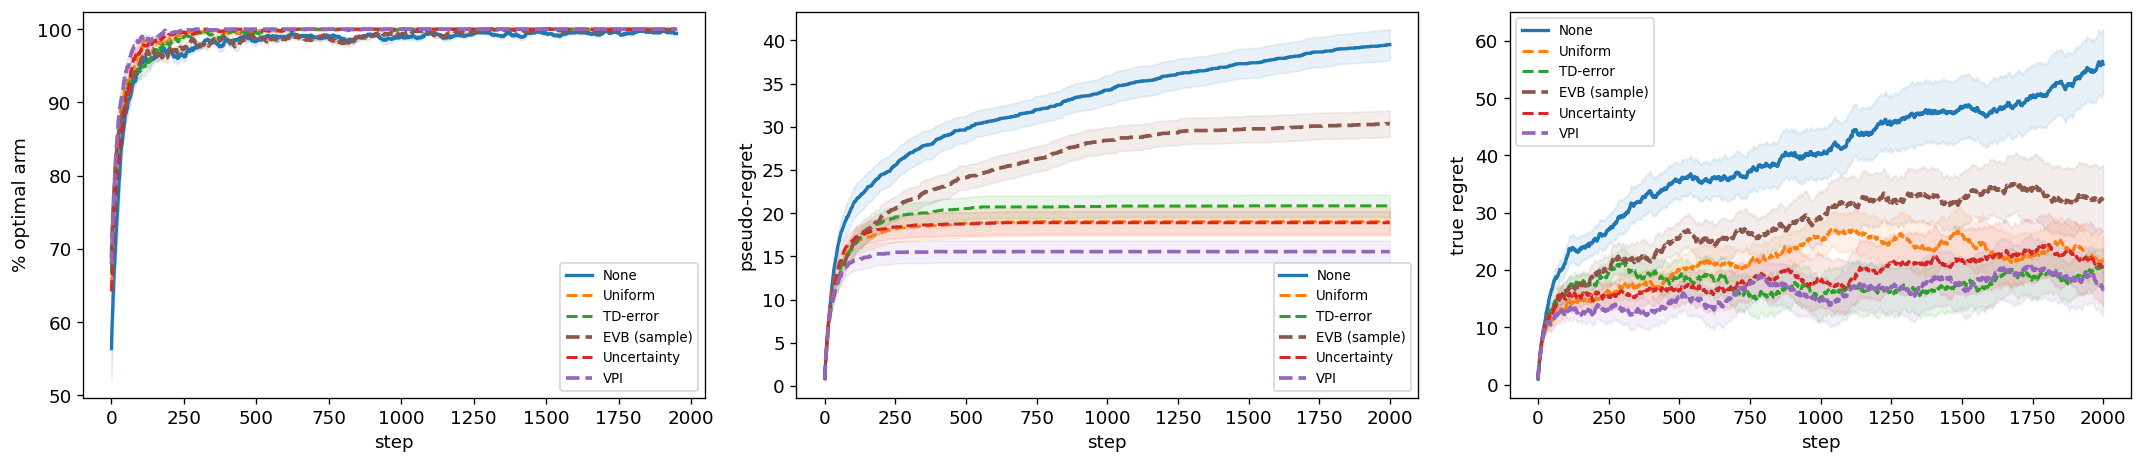

In [12]:
def smooth(x):
    return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")

STYLES = {
    "No replay":          ("C0", "-",  2.0, "None"),
    "Uniform replay":     ("C1", "--", 1.8, "Uniform"),
    "TD-error replay":    ("C2", "--", 1.8, "TD-error"),
    "Uncertainty replay": ("C3", "--", 1.8, "Uncertainty"),
    "VPI replay":         ("C4", "--", 2.2, "VPI"),
    "EVB replay":         ("C5", "--", 2.2, "EVB (sample)"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for scheme, data in results.items():
    color, ls, lw, capt = STYLES[scheme]

    # --- optimal-arm rate (smoothed)
    opt_sm  = np.array([smooth(row) for row in data["optimal"]]) * 100
    steps   = np.arange(opt_sm.shape[1])
    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, label=capt, color=color, ls=ls, lw=lw)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt, color=color, alpha=0.10)

    # --- cumulative pseudo-regret: Σ(μ* − μ_chosen)  [monotone by construction]
    pseudo_reg = (MEANS[OPT] - MEANS[data["actions"]]).cumsum(1)
    mu_pr  = pseudo_reg.mean(0)
    sem_pr = pseudo_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_pr, label=capt, color=color, ls=ls, lw=lw)
    axes[1].fill_between(np.arange(N_STEPS), mu_pr - sem_pr, mu_pr + sem_pr,
                         color=color, alpha=0.10)

    # --- cumulative true regret: Σ(μ* − r_t)  [non-monotone due to reward noise]
    true_reg = (MEANS[OPT] - data["rewards"]).cumsum(1)
    mu_tr  = true_reg.mean(0)
    sem_tr = true_reg.std(0) / np.sqrt(N_SEEDS)
    axes[2].plot(mu_tr, label=capt, color=color, ls=ls, lw=lw)
    axes[2].fill_between(np.arange(N_STEPS), mu_tr - sem_tr, mu_tr + sem_tr,
                         color=color, alpha=0.10)

axes[0].set(xlabel="step", ylabel="% optimal arm")
            # title=f"Thompson sampling — replay comparison\n({cfg['description']})")
axes[1].set(xlabel="step", ylabel="pseudo-regret")
            # title=r"Cumulative pseudo-regret  $\sum(\mu^* - \mu_{a_t})$")
axes[2].set(xlabel="step", ylabel="true regret")
            # title=r"Cumulative true regret  $\su(\mu^* - r_t)$")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

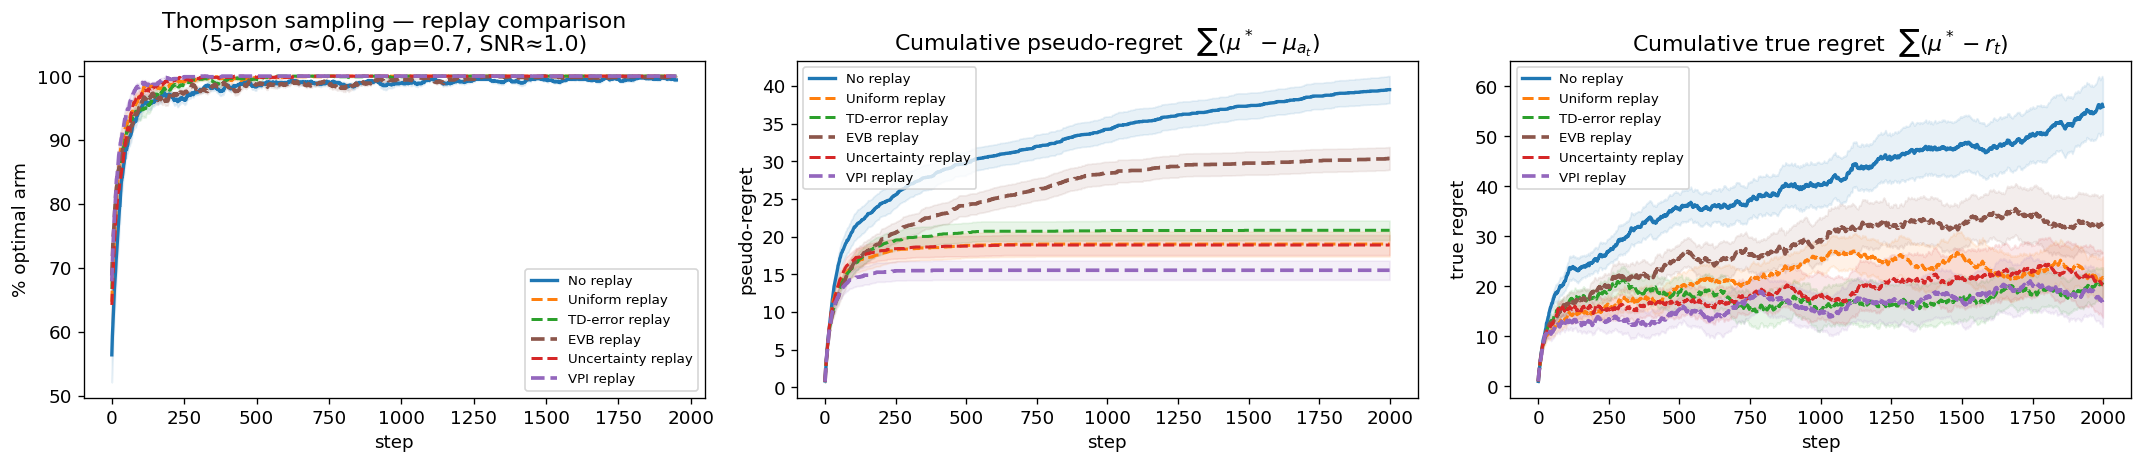

In [68]:
def smooth(x):
    return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")

STYLES = {
    "No replay":          ("C0", "-",  2.0),
    "Uniform replay":     ("C1", "--", 1.8),
    "TD-error replay":    ("C2", "--", 1.8),
    "Uncertainty replay": ("C3", "--", 1.8),
    "VPI replay":         ("C4", "--", 2.2),
    "EVB replay":         ("C5", "--", 2.2),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for scheme, data in results.items():
    color, ls, lw = STYLES[scheme]

    # --- optimal-arm rate (smoothed)
    opt_sm  = np.array([smooth(row) for row in data["optimal"]]) * 100
    steps   = np.arange(opt_sm.shape[1])
    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, label=scheme, color=color, ls=ls, lw=lw)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt, color=color, alpha=0.10)

    # --- cumulative pseudo-regret: Σ(μ* − μ_chosen)  [monotone by construction]
    pseudo_reg = (MEANS[OPT] - MEANS[data["actions"]]).cumsum(1)
    mu_pr  = pseudo_reg.mean(0)
    sem_pr = pseudo_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_pr, label=scheme, color=color, ls=ls, lw=lw)
    axes[1].fill_between(np.arange(N_STEPS), mu_pr - sem_pr, mu_pr + sem_pr,
                         color=color, alpha=0.10)

    # --- cumulative true regret: Σ(μ* − r_t)  [non-monotone due to reward noise]
    true_reg = (MEANS[OPT] - data["rewards"]).cumsum(1)
    mu_tr  = true_reg.mean(0)
    sem_tr = true_reg.std(0) / np.sqrt(N_SEEDS)
    axes[2].plot(mu_tr, label=scheme, color=color, ls=ls, lw=lw)
    axes[2].fill_between(np.arange(N_STEPS), mu_tr - sem_tr, mu_tr + sem_tr,
                         color=color, alpha=0.10)

axes[0].set(xlabel="step", ylabel="% optimal arm",
            title=f"Thompson sampling — replay comparison\n({cfg['description']})")
axes[1].set(xlabel="step", ylabel="pseudo-regret",
            title=r"Cumulative pseudo-regret  $\sum(\mu^* - \mu_{a_t})$")
axes[2].set(xlabel="step", ylabel="true regret",
            title=r"Cumulative true regret  $\sum(\mu^* - r_t)$")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()